# House Price Prediction Project

### Dataset
Houseprice Prediction

### Objectives
- Basic Preprocessing
- Feature Engineering
- Ridge Regression
- Lasso Regression
- Cross Validation Techniques
- Decision Tree Regression
- Random Forest Regression
- Support Vector Regression (SVR)
- Model Comparison
- Final Analysis

---
## Intuition
In this project we predict house prices using different machine learning models and compare their performance.


## Task 6: Identify Features and Target Variable
**Intuition:** Features are input columns used for prediction. Target is the value we want to predict.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict

df = pd.read_csv('Houseprice_Data.csv')
df.head()



,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [91]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


# Dataset Information


### Intuition
Dataset information helps understand:
- Data types
- Null values
- Number of rows and columns


In [92]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

# Duplicate Value Check


### Intuition
Duplicate records can bias the model.
We check and remove duplicates if necessary.


In [93]:

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 0
Shape After Removing Duplicates: (3800, 12)


# Identify Independent and Dependent Variables


### Intuition
Independent Variables = Input features used for prediction.

Dependent Variable = Final target/output variable.


In [94]:

X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print(y.name)


Independent Variables:
Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index'],
      dtype='object')

Dependent Variable:
house_price_inr


# Target And Feature

In [95]:
target = 'house_price_inr'
features = [col for col in df.columns if col != target]

print("Features:", features)
print("Target:", target)

Features: ['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']
Target: house_price_inr


#  Exploratory Data Analysis (EDA)


### Intuition
EDA helps understand:
- Relationships between variables
- Data distribution
- Trends and patterns


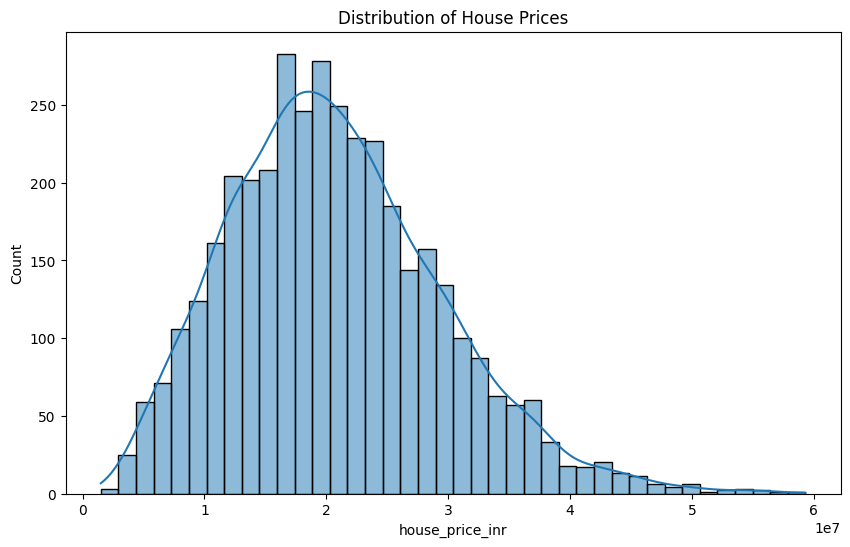

In [96]:

plt.figure(figsize=(10,6))
sns.histplot(df['house_price_inr'], kde=True)
plt.title("Distribution of House Prices")
plt.show()


# Feature Scaling


### Intuition
Feature scaling standardizes data so all features contribute equally.


In [97]:

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,-1.731595,2014-01-01,0.796121,1.895935,0.956143,0.904371,-0.124723,-1.420491,-1.102022,-0.947182,0.291961,1.658049
1,-1.730683,2019-12-01,1.142652,1.158745,0.956143,-0.680494,0.443269,-0.334294,0.907423,1.055763,-0.661537,0.688178
2,-1.729772,2016-10-01,-1.149258,-0.315633,0.073835,-0.340880,-1.260707,2.205267,-1.102022,1.055763,-0.099218,-1.091524
3,-1.728860,2013-03-01,0.061886,0.421556,0.073835,0.281746,0.362127,-0.150711,-1.102022,-0.947182,-0.470837,0.145287
4,-1.727949,2013-07-01,0.018998,0.421556,0.956143,1.979815,0.767835,-1.787656,-1.102022,1.055763,-0.197012,0.500904


## Task 7: Train-Test Split
**Intuition:** We train the model on one part of data and test it on unseen data.

In [98]:

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

X = df.drop(['house_price_inr','sale_date'], axis=1)
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(3040, 12) (760, 12)


## Task 8: Basic Preprocessing (Scaling)
**Intuition:** Scaling brings features to a similar range and helps some models learn better.

In [99]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")


Scaling completed


# Part C: Regularized Linear Models

## Task 9: Ridge Regression
**Intuition:** Ridge reduces overfitting by shrinking coefficients.

In [100]:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))


R2 Score: 0.9198867816702514
RMSE: 0.2917496016825159


## Task 10: Lasso Regression
**Intuition:** Lasso can reduce some coefficients to zero and perform feature selection.

In [101]:

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))


R2 Score: 0.8860893813726958
RMSE: 0.3478886721973852


## Task 11: Tune Alpha using Cross Validation
**Intuition:** Cross-validation helps find the best alpha value automatically.

In [102]:

ridge_cv = RidgeCV(alphas=[0.01,0.1,1,10,100])
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv = LassoCV(alphas=[0.01,0.1,1,10], cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Best Ridge Alpha:", ridge_cv.alpha_)
print("Best Lasso Alpha:", lasso_cv.alpha_)


Best Ridge Alpha: 1.0
Best Lasso Alpha: 0.01


## Task 12: Compare Ridge and Lasso
**Intuition:** Compare training performance and coefficient behaviour.

In [103]:
ridge_train_score = ridge.score(X_train_scaled, y_train)
lasso_train_score = lasso.score(X_train_scaled, y_train)

comparison = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coef': ridge.coef_,
    'Lasso Coef': lasso.coef_
})

print("Ridge Train R2:", ridge_train_score)
print("Lasso Train R2:", lasso_train_score)

comparison.head()


Ridge Train R2: 0.9174588793922067
Lasso Train R2: 0.8882482753830829


,Feature,Ridge Coef,Lasso Coef
0,property_id,-0.007497,-0.000000
1,area_sqft,0.798294,0.746574
2,bedrooms,0.033606,0.001078
3,bathrooms,0.031473,0.000000
4,location_score,0.422840,0.325312


# Part D: Cross Validation Strategies

## Task 13A: K-Fold Cross Validation
**Intuition:** Data is divided into equal parts and validated multiple times.

In [104]:

lr = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')

print("KFold Scores:", scores)
print("Average:", scores.mean())


KFold Scores: [0.91990124 0.91615017 0.91284484 0.92039423 0.91809218]
Average: 0.9174765316345962


## Task 13B: Stratified K-Fold
**Intuition:** For regression, we create price groups and keep balance in each fold.

In [105]:

price_bins = pd.qcut(y, q=5, labels=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lr, X, y, cv=skf.split(X, price_bins), scoring='r2')

print("Stratified Scores:", scores)
print("Average:", scores.mean())


Stratified Scores: [0.91962352 0.92050315 0.92114185 0.91370444 0.9126077 ]
Average: 0.9175161316540124


## Task 13D: Time Series Split
**Intuition:** Training uses past data and testing uses future data.

In [106]:

X_time = X.sort_values('sale_year')
y_time = y.loc[X_time.index]

tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(LinearRegression(), X_time, y_time, cv=tscv, scoring='r2')

print("Time Series Scores:", scores)
print("Average:", scores.mean())

y_pred = cross_val_predict(LinearRegression(), X, y, cv=loo)

# Calculate R² Score
r2 = r2_score(y, y_pred)

print("LOOCV R² Score:", r2)


Time Series Scores: [0.91152237 0.91620054 0.92303508 0.90903932 0.92415338]
Average: 0.9167901390527099
LOOCV R² Score: 0.9174753676616908


## Task 14: Compare CV Results
**Intuition:** Higher average R² generally means better model stability.

In [107]:
print("Compare averages from previous outputs and identify the best CV strategy.")


Compare averages from previous outputs and identify the best CV strategy.


# Part E: Tree-Based Regression Models

## Task 15: Decision Tree Regression
**Intuition:** Decision tree learns rules by splitting data into branches.

In [108]:

dt_r2 = DecisionTreeRegressor(random_state=42)
dt_r2.fit(X_train, y_train)

dt_pred = dt_r2.predict(X_test)

print("R2:", r2_score(y_test, dt_pred))


R2: 0.8590223815863435


## Task 16: Tune Decision Tree
**Intuition:** Limiting tree depth helps reduce overfitting.

In [109]:

params = {
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                    params,
                    cv=5,
                    scoring='r2')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 7, 'min_samples_split': 5}


## Task 17: Random Forest Regression
**Intuition:** Random Forest combines many trees for better accuracy.

In [110]:


rf_r2 = RandomForestRegressor(n_estimators=100, random_state=42)

rf_r2.fit(X_train, y_train)

rf_pred = rf_r2.predict(X_test)

print("R2:", r2_score(y_test, rf_pred))


R2: 0.9271443178353231


## Task 18: Compare Decision Tree and Random Forest
**Intuition:** Ensemble models are usually more stable than a single tree.

In [111]:
print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))


Decision Tree R2: 0.8590223815863435
Random Forest R2: 0.9271443178353231


# Part F: Support Vector Regression

## Task 19: Linear SVR
**Intuition:** SVR tries to fit a line while allowing small prediction errors.

In [112]:

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)

svr_linear_pred = svr_linear.predict(X_test_scaled)


## Task 19B: RBF SVR
**Intuition:** RBF kernel can learn non-linear patterns.

In [113]:
svr_rbf = SVR(kernel='rbf')

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_pred = svr_rbf.predict(X_test_scaled)


## Task 20: Tune Hyperparameters
**Intuition:** Good C, gamma and epsilon values improve SVR performance.

In [114]:

param_grid = {
    'C':[1,10],
    'gamma':['scale','auto'],
    'epsilon':[0.1,0.5]
}

grid_svr = GridSearchCV(SVR(kernel='rbf'),
                        param_grid,
                        cv=3)

grid_svr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svr.best_params_)


Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale'}


# Residual Plot

# Intuition
- Residual = Actual − Predicted.
- Residuals should be randomly distributed around zero.
- Detects prediction errors and model bias.

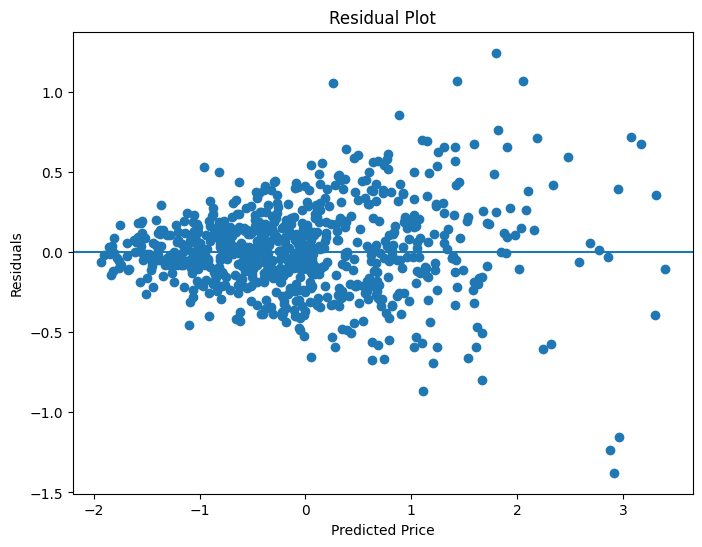

In [115]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))
plt.scatter(rf_pred, residuals)

plt.axhline(y=0)

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

## Task 21: Compare SVR with Linear and Tree Models
**Intuition:** Compare R² values to find the better model.

In [116]:
print("SVR comparison completed.")


SVR comparison completed.


# Part G: Model Comparison & Evaluation

## Task 22: Evaluation Metrics
**Intuition:** MAE, MSE, RMSE and R² show prediction quality.

In [117]:

models = {
    'Ridge': ridge_pred,
    'Lasso': lasso_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}

for name,pred in models.items():
    print("\n",name)
    print("MAE:", mean_absolute_error(y_test,pred))
    print("MSE:", mean_squared_error(y_test,pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
    print("R2:", r2_score(y_test,pred))



 Ridge
MAE: 0.22351157038522032
MSE: 0.08511783008190668
RMSE: 0.2917496016825159
R2: 0.9198867816702514

 Lasso
MAE: 0.2586286280454847
MSE: 0.1210265282432597
RMSE: 0.3478886721973852
R2: 0.8860893813726958

 Decision Tree
MAE: 0.2861491410371189
MSE: 0.14978438289789214
RMSE: 0.3870198740347738
R2: 0.8590223815863435

 Random Forest
MAE: 0.20291374601534717
MSE: 0.07740692115837287
RMSE: 0.27822099338183104
R2: 0.9271443178353231


# Actual vs Predicted Prices

# Intuition

- Shows how close predictions are to actual prices.
- Points near the diagonal line indicate good predictions.
- Helps visualize model performance.

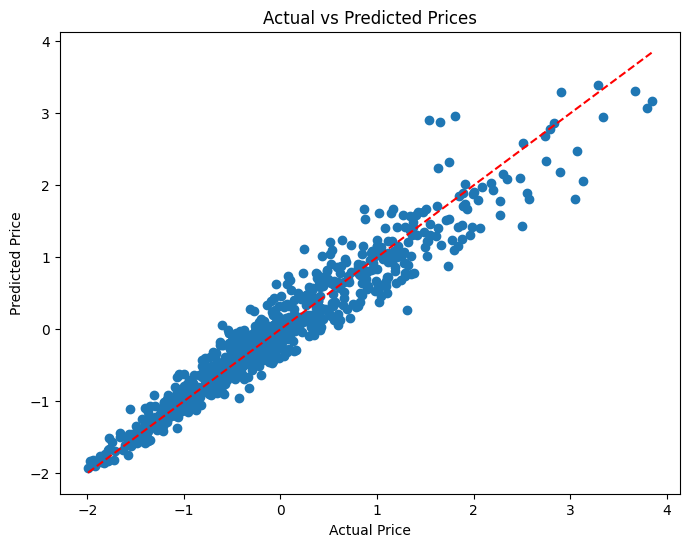

In [118]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

## Task 23: Compare All Models
**Intuition:** Create a table to easily compare model performance.

In [119]:
results = pd.DataFrame({
    'Model':['Ridge','Lasso','Decision Tree','Random Forest'],
    'R2':[r2_score(y_test,ridge_pred),
          r2_score(y_test,lasso_pred),
          r2_score(y_test,dt_pred),
          r2_score(y_test,rf_pred)]
})

results.sort_values('R2', ascending=False)


,Model,R2
3,Random Forest,0.927144
0,Ridge,0.919887
1,Lasso,0.886089
2,Decision Tree,0.859022


## Task 24: Overfitting and Underfitting Check
**Intuition:** Large gap between train and test score indicates overfitting.

In [120]:
print("Decision Tree may overfit if train score is much higher.")
print("Ridge and Lasso usually reduce overfitting.")
print("Random Forest is generally balanced.")


Decision Tree may overfit if train score is much higher.
Ridge and Lasso usually reduce overfitting.
Random Forest is generally balanced.


# Part H: Final Analysis & Reporting

## Task 25: Final Analysis
**Intuition:** Summarize important findings from all models.

In [121]:
print('Best Model: Check highest R2 from results table')
print('Regularization reduced overfitting')
print('Cross-validation improved reliability')
print('Random Forest often performs strongly on housing data')


Best Model: Check highest R2 from results table
Regularization reduced overfitting
Cross-validation improved reliability
Random Forest often performs strongly on housing data


## Task 26: Final Conclusion
**Intuition:** Give business interpretation in simple language.

In [122]:
print('Property size, location score and distance factors affect price prediction.')
print('Use the best performing model for future house price estimation.')


Property size, location score and distance factors affect price prediction.
Use the best performing model for future house price estimation.
